In [72]:
## Import Libraries

In [73]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import (ENGLISH_STOP_WORDS, CountVectorizer,
                                             TfidfVectorizer)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split

In [74]:
##Load Dataset

In [75]:
DATA_PATH = "/Users/shresthrastogi/Downloads/IMDB_dataset.csv"

df = pd.read_csv(DATA_PATH)[["review", "sentiment"]].dropna()
print("Shape:", df.shape)
print(df.head())

Shape: (50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [76]:
##EDA


===== 1. EDA =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
Duplicate reviews: 418
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


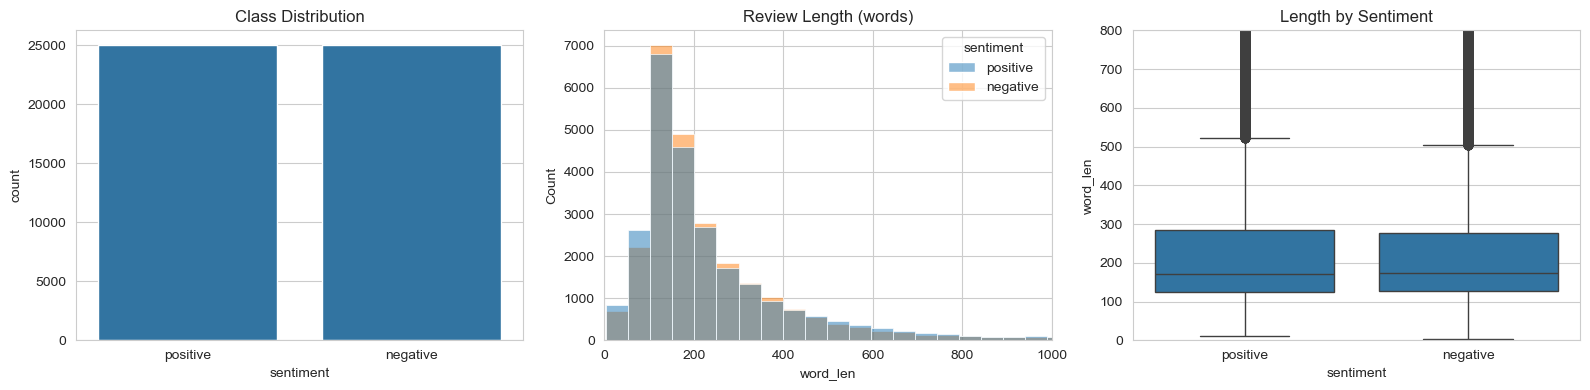

In [77]:
print("\n===== 1. EDA =====")
print(df.info())
print("Duplicate reviews:", df.duplicated().sum())
print(df["sentiment"].value_counts())

df["char_len"] = df["review"].str.len()
df["word_len"] = df["review"].str.split().str.len()

sns.set_style("whitegrid")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x="sentiment", data=df, ax=ax[0])
ax[0].set_title("Class Distribution")

sns.histplot(data=df, x="word_len", hue="sentiment", bins=50, ax=ax[1])
ax[1].set_title("Review Length (words)")
ax[1].set_xlim(0, 1000)

sns.boxplot(x="sentiment", y="word_len", data=df, ax=ax[2])
ax[2].set_title("Length by Sentiment")
ax[2].set_ylim(0, 800)
plt.tight_layout()
plt.show()

In [ ]:
##Data Quality Checks


===== 1.1 DATA QUALITY =====
Missing values:
 review       0
sentiment    0
dtype: int64 

Rows involved in duplicated reviews : 824
Extra duplicate copies (drop-able)  : 418
Duplicated reviews with conflicting labels: 0

Shortest reviews (words): [4, 6, 8, 8, 9]
Reviews with < 10 words : 5
Empty reviews           : 0

% of reviews that...
contain HTML tags (<br />)    58.40
contain URLs                   0.41
contain digits                56.01
contain non-ASCII chars        9.32


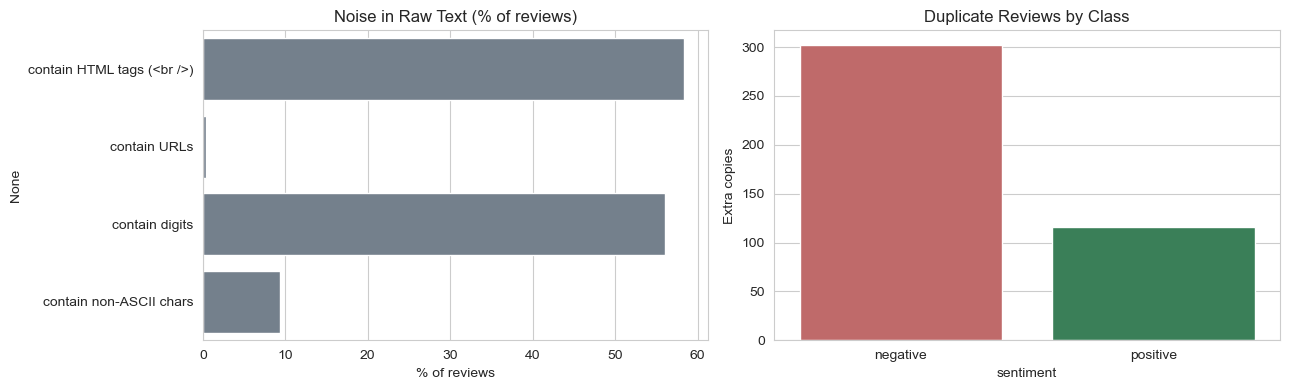

In [78]:
print("\n===== 1.1 DATA QUALITY =====")

# --- missing / duplicates ---
print("Missing values:\n", df[["review", "sentiment"]].isna().sum(), "\n")
dup_mask = df.duplicated("review", keep=False)
print(f"Rows involved in duplicated reviews : {dup_mask.sum()}")
print(f"Extra duplicate copies (drop-able)  : {df.duplicated('review').sum()}")

# do duplicate reviews ever carry conflicting labels?
conflicts = (df[dup_mask].groupby("review")["sentiment"].nunique() > 1).sum()
print(f"Duplicated reviews with conflicting labels: {conflicts}")

# --- short / empty reviews ---
print("\nShortest reviews (words):", df["word_len"].nsmallest(5).tolist())
print("Reviews with < 10 words :", (df["word_len"] < 10).sum())
print("Empty reviews           :", (df["review"].str.strip() == "").sum())

# --- noise present in raw text ---
noise = pd.Series({
    "contain HTML tags (<br />)": df["review"].str.contains(r"<.*?>", regex=True).mean(),
    "contain URLs":               df["review"].str.contains(r"http\S+|www\.", regex=True).mean(),
    "contain digits":             df["review"].str.contains(r"\d", regex=True).mean(),
    "contain non-ASCII chars":    df["review"].apply(lambda t: not t.isascii()).mean(),
}) * 100
print("\n% of reviews that...")
print(noise.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=noise.values, y=noise.index, ax=ax[0], color="slategray")
ax[0].set_title("Noise in Raw Text (% of reviews)")
ax[0].set_xlabel("% of reviews")

dup_counts = df.groupby("sentiment")["review"].apply(lambda s: s.duplicated().sum())
sns.barplot(x=dup_counts.index, y=dup_counts.values, ax=ax[1], hue=dup_counts.index, legend=False,
            palette={"positive": "seagreen", "negative": "indianred"})
ax[1].set_title("Duplicate Reviews by Class")
ax[1].set_ylabel("Extra copies")
plt.tight_layout()
plt.show()

In [ ]:
##Most Frequent Words and Phrases


===== 1.4 WORD & PHRASE FREQUENCIES =====


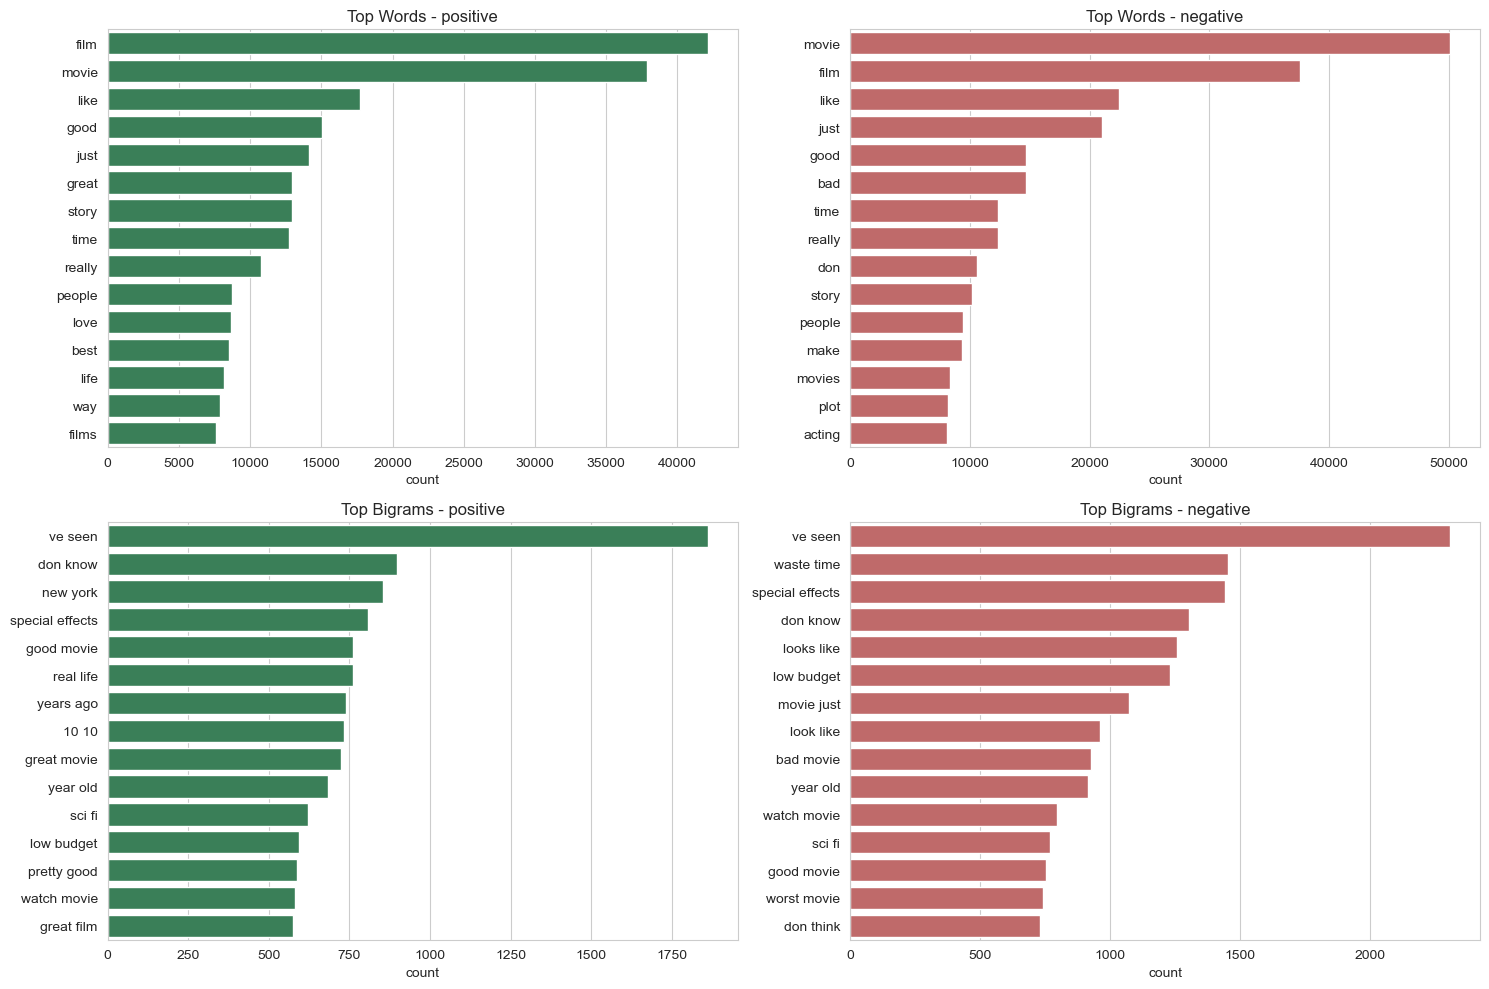

In [79]:
print("\n===== 1.4 WORD & PHRASE FREQUENCIES =====")

def _strip_html(text):
    return re.sub(r"<.*?>", " ", text.lower())

def top_ngrams(texts, ngram, n=15):
    cv = CountVectorizer(ngram_range=(ngram, ngram), stop_words="english",
                         preprocessor=_strip_html, max_features=20000)
    counts = np.asarray(cv.fit_transform(texts).sum(axis=0)).ravel()
    idx = counts.argsort()[::-1][:n]
    return pd.DataFrame({"term": cv.get_feature_names_out()[idx], "count": counts[idx]})

colors = {"positive": "seagreen", "negative": "indianred"}
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
for j, label in enumerate(["positive", "negative"]):
    texts = df.loc[df["sentiment"] == label, "review"]
    for i, (n, name) in enumerate([(1, "Words"), (2, "Bigrams")]):
        t = top_ngrams(texts, n)
        sns.barplot(x="count", y="term", data=t, ax=ax[i, j], color=colors[label])
        ax[i, j].set_title(f"Top {name} - {label}")
        ax[i, j].set_ylabel("")
plt.tight_layout()
plt.show()

In [ ]:
##Most Discriminative Words


===== 1.5 DISCRIMINATIVE WORDS =====


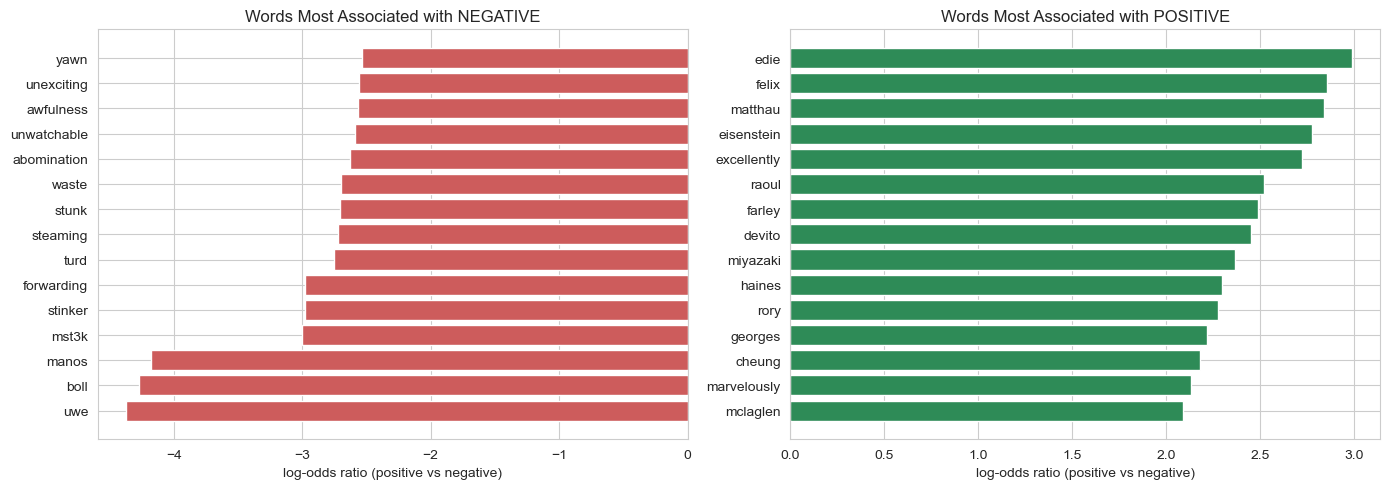

Vocabulary size (raw, no stop-word removal): 101,888
Words kept with min_df=50 (stop-words removed): 9,891


In [80]:
print("\n===== 1.5 DISCRIMINATIVE WORDS =====")

cv = CountVectorizer(stop_words="english", preprocessor=_strip_html, min_df=50)
X_counts = cv.fit_transform(df["review"])
vocab = np.array(cv.get_feature_names_out())

is_pos = (df["sentiment"] == "positive").values
pos_counts = np.asarray(X_counts[is_pos].sum(axis=0)).ravel() + 1    # +1 smoothing
neg_counts = np.asarray(X_counts[~is_pos].sum(axis=0)).ravel() + 1

log_odds = np.log(pos_counts / pos_counts.sum()) - np.log(neg_counts / neg_counts.sum())
order = log_odds.argsort()
neg_idx, pos_idx = order[:15], order[-15:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(vocab[neg_idx], log_odds[neg_idx], color="indianred")
ax[0].set_title("Words Most Associated with NEGATIVE")
ax[1].barh(vocab[pos_idx], log_odds[pos_idx], color="seagreen")
ax[1].set_title("Words Most Associated with POSITIVE")
for a in ax:
    a.set_xlabel("log-odds ratio (positive vs negative)")
plt.tight_layout()
plt.show()

# vocabulary size & rarity
total_vocab = len(CountVectorizer(preprocessor=_strip_html).fit(df["review"]).vocabulary_)
word_freq = np.asarray(X_counts.sum(axis=0)).ravel()
print(f"Vocabulary size (raw, no stop-word removal): {total_vocab:,}")
print(f"Words kept with min_df=50 (stop-words removed): {len(vocab):,}")

In [ ]:
##Sample Reviews

In [81]:
print("\n===== 1.6 SAMPLE REVIEWS =====")

for label in ["positive", "negative"]:
    print(f"\n--- {label.upper()} ---")
    for _, row in df[df["sentiment"] == label].sample(2, random_state=7).iterrows():
        print(f"[{row['word_len']} words] {row['review'][:300]}...\n")

print("--- SHORTEST review ---")
print(df.loc[df["word_len"].idxmin(), "review"])
print("\n--- Key takeaways ---")
print("* Classes are perfectly balanced -> accuracy is a fair metric.")
print("* Reviews contain HTML (<br />) -> must be stripped in preprocessing.")
print("* Duplicates exist -> consider dropping them to avoid train/test leakage.")
print("* Length is right-skewed with long outliers -> TF-IDF (length-normalised) suits this well.")


===== 1.6 SAMPLE REVIEWS =====

--- POSITIVE ---
[127 words] Another detailed work on the subject by Dr Dwivedi takes us back in time to pre-partioned Panjab. Dr Dwivedi chose a difficult subject for his movie debut. He has worked on all meticulous details to bring the story to life. The treatment of the subject is very delicate.<br /><br />Even though we hav...

[117 words] Although the plot was a bit sappy at times, and VERY rushed at the end, as if the director had run out of his alloted time and needed to hurry up and finish the story, overall it was pretty good for the Made-For-Backwoods-Cable-TV genre. <br /><br />However, the actress who played the babysitter, Ma...


--- NEGATIVE ---
[140 words] I really like Kinski he is a great actor. I've seen this movie because I've heard that there are autobiographic aspects in this movie.<br /><br />The film is full of symbols like a piano sinking in a river or strange shadow-pictures at the walls. Then the narrator always says abstract 

In [ ]:
##Remove Duplicate Reviews

In [82]:
print("\n===== 1.7 DROP DUPLICATES =====")

before = len(df)
df = df.drop_duplicates(subset="review", keep="first").reset_index(drop=True)
print(f"Rows before: {before} | after: {len(df)} | removed: {before - len(df)}")
print("Remaining duplicates:", df.duplicated("review").sum())
print(df["sentiment"].value_counts())


===== 1.7 DROP DUPLICATES =====
Rows before: 50000 | after: 49582 | removed: 418
Remaining duplicates: 0
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [83]:
#Tokenisation 


===== 2. TOKENIZATION =====
Example review : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with ...
Example tokens : ['one', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', 'oz', 'episode', "you'll", 'be']


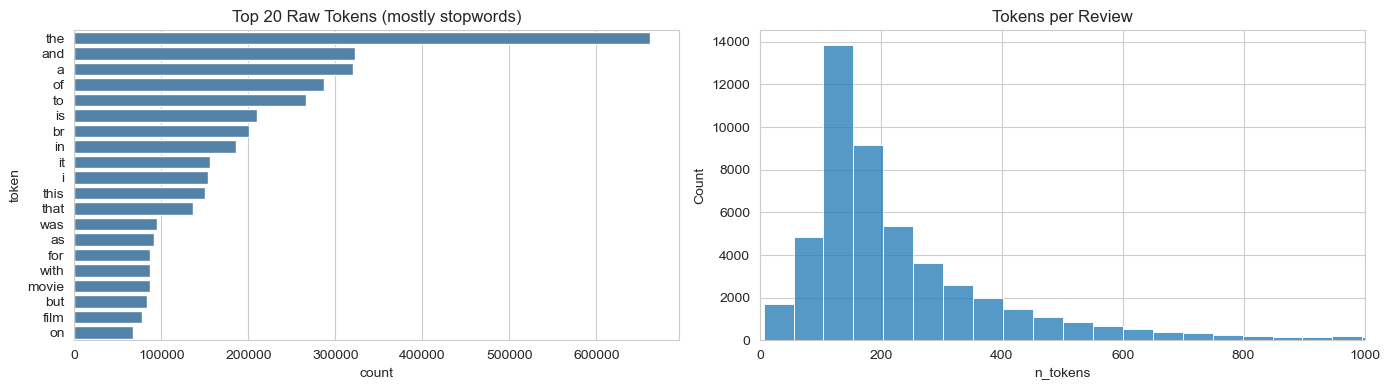

In [84]:
print("\n===== 2. TOKENIZATION =====")


def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())


df["tokens"] = df["review"].apply(tokenize)
df["n_tokens"] = df["tokens"].apply(len)

print("Example review :", df["review"].iloc[0][:150], "...")
print("Example tokens :", df["tokens"].iloc[0][:15])

all_tokens = Counter(t for toks in df["tokens"] for t in toks)
top = pd.DataFrame(all_tokens.most_common(20), columns=["token", "count"])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x="count", y="token", data=top, ax=ax[0], color="steelblue")
ax[0].set_title("Top 20 Raw Tokens (mostly stopwords)")
sns.histplot(df["n_tokens"], bins=50, ax=ax[1])
ax[1].set_title("Tokens per Review")
ax[1].set_xlim(0, 1000)
plt.tight_layout()
plt.show()

In [85]:
##Pre-Processing


===== 3. PREPROCESSING =====
BEFORE: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with
AFTER : reviewers mentioned watching just oz episode ll hooked right exactly happened thing struck oz brutality unflinching scenes violence set right word tru


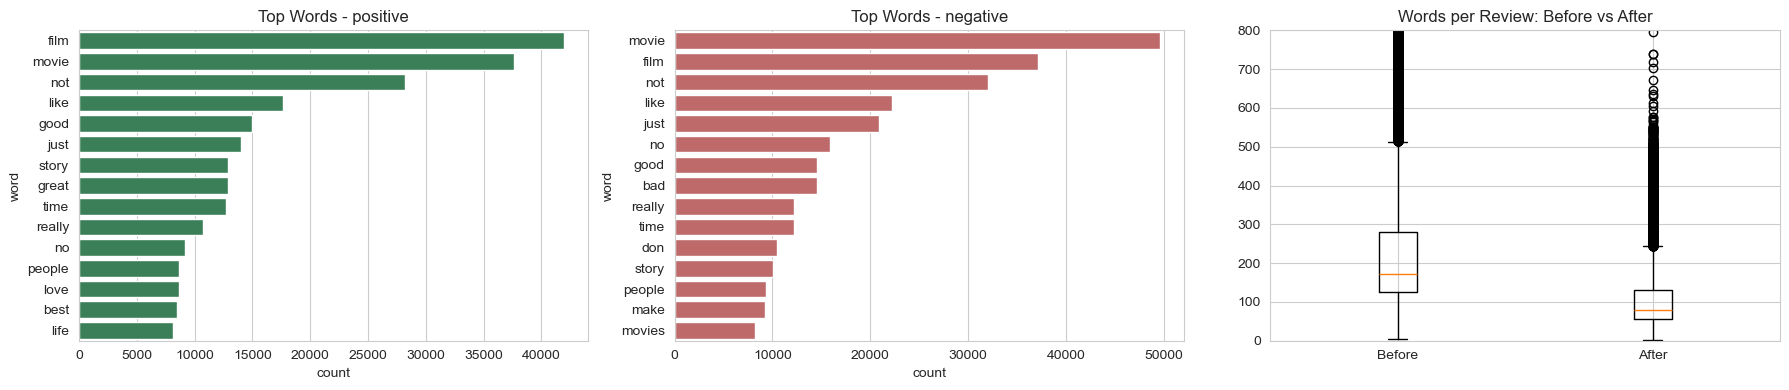

In [86]:
print("\n===== 3. PREPROCESSING =====")

# keep negation words ("not", "no", "never") because they matter for sentiment
STOP_WORDS = set(ENGLISH_STOP_WORDS) - {"not", "no", "nor", "never", "cannot"}


def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)       # remove HTML tags like <br />
    text = re.sub(r"[^a-z\s]", " ", text)    # keep letters only
    words = [w for w in text.split() if w not in STOP_WORDS and len(w) > 1]
    return " ".join(words)


df["clean"] = df["review"].apply(clean_text)
df["clean_len"] = df["clean"].str.split().str.len()

print("BEFORE:", df["review"].iloc[0][:150])
print("AFTER :", df["clean"].iloc[0][:150])

# top words per class after cleaning
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for i, label in enumerate(["positive", "negative"]):
    words = Counter(w for t in df.loc[df.sentiment == label, "clean"] for w in t.split())
    t = pd.DataFrame(words.most_common(15), columns=["word", "count"])
    sns.barplot(x="count", y="word", data=t, ax=ax[i],
                color="seagreen" if label == "positive" else "indianred")
    ax[i].set_title(f"Top Words - {label}")

ax[2].boxplot([df["word_len"], df["clean_len"]])
ax[2].set_xticklabels(["Before", "After"])
ax[2].set_title("Words per Review: Before vs After")
ax[2].set_ylim(0, 800)
plt.tight_layout()
plt.show()

In [87]:
##Feature Engineering


===== 4. FEATURE ENGINEERING (TF-IDF) =====
Train matrix: (39665, 5000) | Test matrix: (9917, 5000)


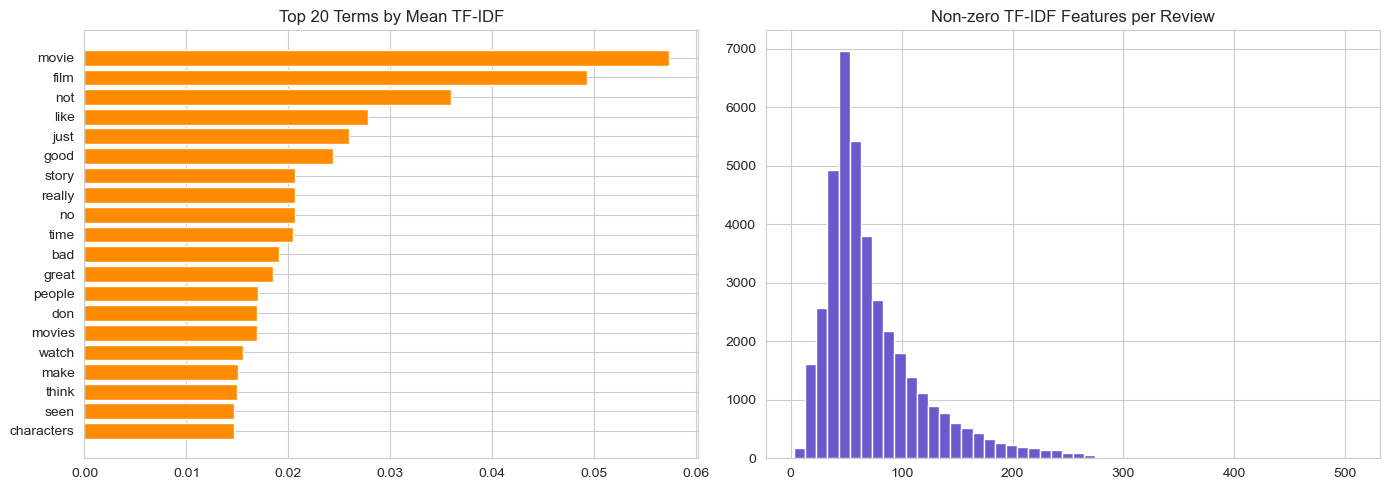

In [88]:
print("\n===== 4. FEATURE ENGINEERING (TF-IDF) =====")

df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5)
X_train = tfidf.fit_transform(X_train_text)   # fit on train only
X_test = tfidf.transform(X_test_text)         # avoid data leakage

print("Train matrix:", X_train.shape, "| Test matrix:", X_test.shape)

features = np.array(tfidf.get_feature_names_out())
mean_tfidf = np.asarray(X_train.mean(axis=0)).ravel()
top_idx = mean_tfidf.argsort()[-20:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(features[top_idx], mean_tfidf[top_idx], color="darkorange")
ax[0].set_title("Top 20 Terms by Mean TF-IDF")

nonzero_per_doc = np.diff(X_train.indptr)
ax[1].hist(nonzero_per_doc, bins=50, color="slateblue")
ax[1].set_title("Non-zero TF-IDF Features per Review")
plt.tight_layout()
plt.show()

In [89]:
##Modelling


===== 5. MODELLING =====
Model trained.


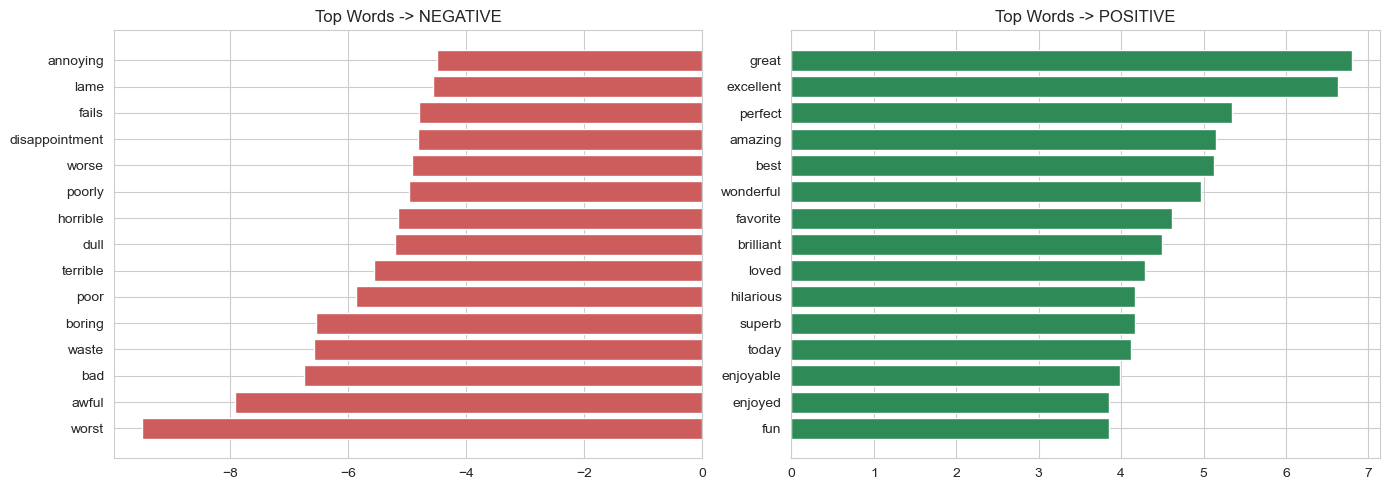

In [90]:
print("\n===== 5. MODELLING =====")

model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train, y_train)
print("Model trained.")

# most influential words
coefs = model.coef_[0]
order = coefs.argsort()
neg_idx, pos_idx = order[:15], order[-15:]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].barh(features[neg_idx], coefs[neg_idx], color="indianred")
ax[0].set_title("Top Words -> NEGATIVE")
ax[1].barh(features[pos_idx], coefs[pos_idx], color="seagreen")
ax[1].set_title("Top Words -> POSITIVE")
plt.tight_layout()
plt.show()

In [91]:
##Evaluation


===== 6. EVALUATION =====
Accuracy : 0.889
ROC-AUC  : 0.9591

               precision    recall  f1-score   support

    negative       0.90      0.87      0.89      4940
    positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



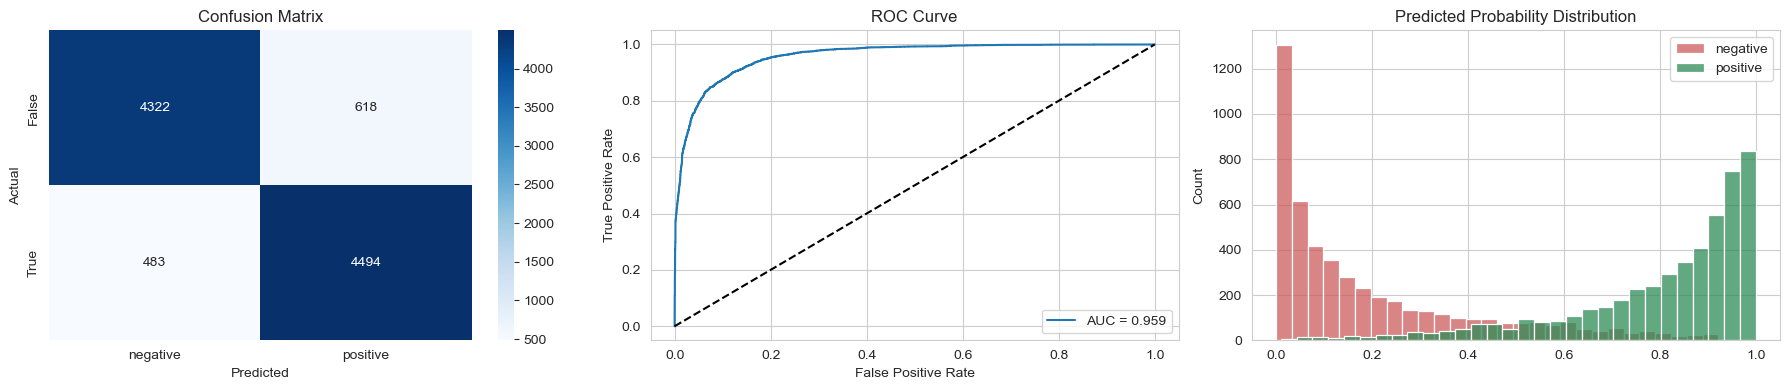

In [92]:
print("\n===== 6. EVALUATION =====")

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("\n", classification_report(y_test, y_pred, target_names=["negative", "positive"]))

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["negative", "positive"], yticklabels=["False", "True"])
ax[0].set_title("Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

fpr, tpr, _ = roc_curve(y_test, y_prob)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set_title("ROC Curve")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

sns.histplot(y_prob[y_test == 0], color="indianred", label="negative", bins=30, ax=ax[2])
sns.histplot(y_prob[y_test == 1], color="seagreen", label="positive", bins=30, ax=ax[2])
ax[2].set_title("Predicted Probability Distribution")
ax[2].legend()
plt.tight_layout()
plt.show()

In [93]:
##Predict new reviews


===== 7. PREDICTION =====
POSITIVE  (0.99) -> An absolutely brilliant movie, great acting and a wonderful story!
NEGATIVE  (0.17) -> Primary plot!Primary direction!Poor interpretation.
NEGATIVE  (0.22) -> It was okay, not great but not bad either.


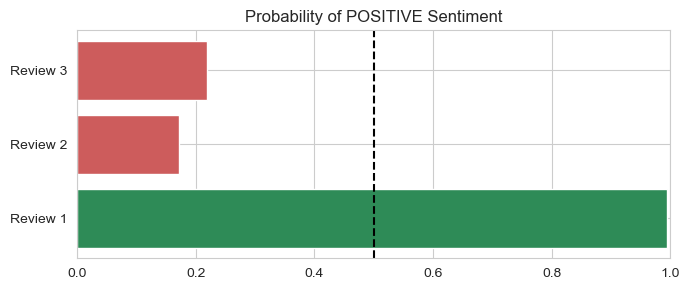

In [94]:
print("\n===== 7. PREDICTION =====")


def predict_sentiment(review):
    vec = tfidf.transform([clean_text(review)])
    prob = model.predict_proba(vec)[0, 1]
    label = "POSITIVE" if prob >= 0.5 else "NEGATIVE"
    return label, prob


samples = [
    "An absolutely brilliant movie, great acting and a wonderful story!",
    "Primary plot!Primary direction!Poor interpretation.",
    "It was okay, not great but not bad either.",
]

results = []
for s in samples:
    label, prob = predict_sentiment(s)
    results.append(prob)
    print(f"{label:9s} ({prob:.2f}) -> {s}")

plt.figure(figsize=(7, 3))
plt.barh([f"Review {i+1}" for i in range(len(samples))], results,
         color=["seagreen" if p >= 0.5 else "indianred" for p in results])
plt.axvline(0.5, color="black", linestyle="--")
plt.xlim(0, 1)
plt.title("Probability of POSITIVE Sentiment")
plt.tight_layout()
plt.show()